# ICA Stochastique — Démo et Comparaison

Ce notebook illustre et compare les quatre algorithmes ICA implémentés :

| Algorithme | Type | Référence |
|---|---|---|
| **Infomax (batch)** | Classique | Bell & Sejnowski (1995) |
| **FastICA (custom)** | Classique | Hyvärinen (1999) |
| **FastICA (sklearn)** | Référence | sklearn baseline |
| **SGD-ICA** | Stochastique | Mini-batch Infomax |
| **Adam-ICA** | Stochastique | Adam + Infomax |

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams['figure.dpi'] = 110

## 1. Génération des données synthétiques

On simule un problème BSS classique :
- **Sources indépendantes** : Laplace (super-gaussienne), sinusoïde (sous-gaussienne), uniforme
- **Mélange** via une matrice aléatoire A

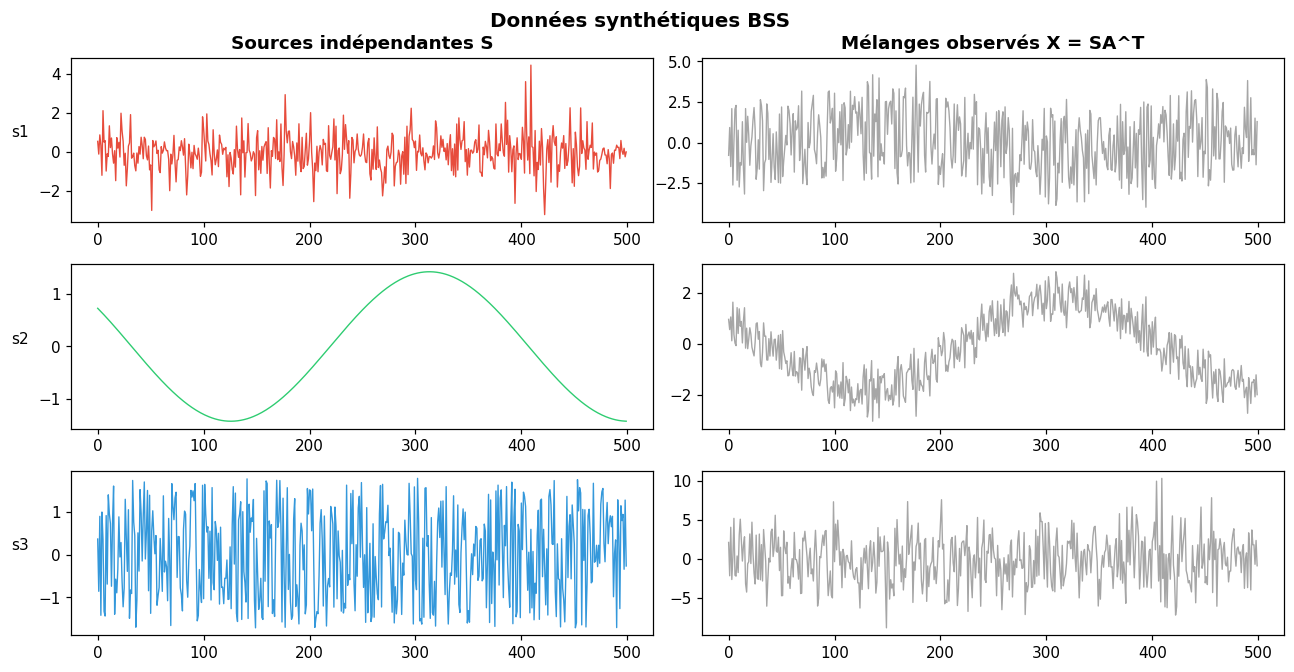

Matrice de mélange A :
[[ 0.483 -0.608 -1.649]
 [-0.287  1.325  0.461]
 [ 2.018  0.177  2.448]]


In [3]:
from experiments.benchmark import make_sources

S, A, X = make_sources(n_samples=3000, n_sources=3, source_type='mixed', random_state=42)

fig, axes = plt.subplots(3, 2, figsize=(12, 6))
t = np.arange(500)
labels_s = ['Laplace (super-G)', 'Sinusoïde (sous-G)', 'Uniforme (sous-G)']
colors = ['#e74c3c', '#2ecc71', '#3498db']

for i in range(3):
    axes[i, 0].plot(t, S[:500, i], color=colors[i], linewidth=0.9)
    axes[i, 0].set_ylabel(f's{i+1}', rotation=0, labelpad=12)
    axes[i, 0].set_title(labels_s[i] if i == 0 else '', fontsize=9)
    axes[i, 1].plot(t, X[:500, i], color='gray', linewidth=0.9, alpha=0.7)

axes[0, 0].set_title('Sources indépendantes S', fontweight='bold')
axes[0, 1].set_title('Mélanges observés X = SA^T', fontweight='bold')
plt.tight_layout()
plt.suptitle('Données synthétiques BSS', y=1.01, fontsize=13, fontweight='bold')
plt.show()
print(f'Matrice de mélange A :\n{A.round(3)}')

## 2. Algorithmes classiques

### 2a. Infomax (gradient batch)

In [3]:
from ica import InfomaxICA

infomax = InfomaxICA(n_components=3, learning_rate=0.01, max_iter=500,
                     random_state=42, verbose=True)
S_infomax = infomax.fit_transform(X)
print(f'\nIterations: {infomax.n_iter_}')

[Infomax] iter    0  LL=-2.261837  ΔV=6.79e-03
[Infomax] iter  100  LL=-2.593633  ΔV=3.44e-03
[Infomax] iter  200  LL=-2.792730  ΔV=1.60e-03
[Infomax] iter  300  LL=-2.861439  ΔV=1.15e-03
[Infomax] iter  400  LL=-2.881666  ΔV=1.02e-03
[Infomax] iter  499  LL=-2.887223  ΔV=9.29e-04

Iterations: 500


### 2b. FastICA (from scratch)

In [ ]:
from ica import FastICACustom

fastica = FastICACustom(n_components=3, g='logcosh', random_state=42, verbose=True)
S_fastica = fastica.fit_transform(X)
print(f'\nIterations par composante: {fastica.n_iter_}')

## 3. Algorithmes stochastiques

### 3a. SGD-ICA

In [10]:
from ica import SGDICA

sgd_ica = SGDICA(n_components=3, learning_rate=0.01, batch_size=64,
                 n_epochs=100, lr_schedule='cosine', random_state=42, verbose=True)
S_sgd = sgd_ica.fit_transform(X)

[SGD-ICA] Epoch   0  avg LL=-2.334780  lr=1.00e-02
[SGD-ICA] Epoch   1  avg LL=-2.489492  lr=9.99e-03
[SGD-ICA] Epoch   2  avg LL=-2.630113  lr=9.98e-03
[SGD-ICA] Epoch   3  avg LL=-2.726852  lr=9.96e-03
[SGD-ICA] Epoch   4  avg LL=-2.795485  lr=9.94e-03
[SGD-ICA] Epoch   5  avg LL=-2.830922  lr=9.91e-03
[SGD-ICA] Epoch   6  avg LL=-2.847714  lr=9.88e-03
[SGD-ICA] Epoch   7  avg LL=-2.875004  lr=9.84e-03
[SGD-ICA] Epoch   8  avg LL=-2.881581  lr=9.80e-03
[SGD-ICA] Epoch   9  avg LL=-2.883697  lr=9.76e-03
[SGD-ICA] Epoch  10  avg LL=-2.881373  lr=9.71e-03
[SGD-ICA] Epoch  11  avg LL=-2.896716  lr=9.65e-03
[SGD-ICA] Epoch  12  avg LL=-2.880935  lr=9.59e-03
[SGD-ICA] Epoch  13  avg LL=-2.872096  lr=9.53e-03
[SGD-ICA] Epoch  14  avg LL=-2.888600  lr=9.46e-03
[SGD-ICA] Epoch  15  avg LL=-2.886370  lr=9.38e-03
[SGD-ICA] Epoch  16  avg LL=-2.879433  lr=9.31e-03
[SGD-ICA] Epoch  17  avg LL=-2.893477  lr=9.22e-03
[SGD-ICA] Epoch  18  avg LL=-2.888242  lr=9.14e-03
[SGD-ICA] Epoch  19  avg LL=-2.

### 3b. Adam-ICA

In [ ]:
from ica import AdamICA

adam_ica = AdamICA(n_components=3, learning_rate=1e-3, batch_size=64,
                   n_epochs=100, random_state=42, verbose=True)
S_adam = adam_ica.fit_transform(X)

## 5. Benchmark complet et métriques

In [2]:
from experiments.benchmark import run_benchmark

print('=== Benchmark ICA ===' )
results = run_benchmark(n_samples=3000, n_components=3, source_type='mixed',
                        random_state=42, verbose=True)

=== Benchmark ICA ===
  Infomax (batch)        Amari=0.4297  time=0.513s
  FastICA (custom)       Amari=0.4279  time=0.007s
  FastICA (sklearn)      Amari=0.3946  time=0.023s
  SGD-ICA                Amari=0.4554  time=0.505s
  Adam-ICA               Amari=0.4577  time=0.627s


## 6. Visualisations


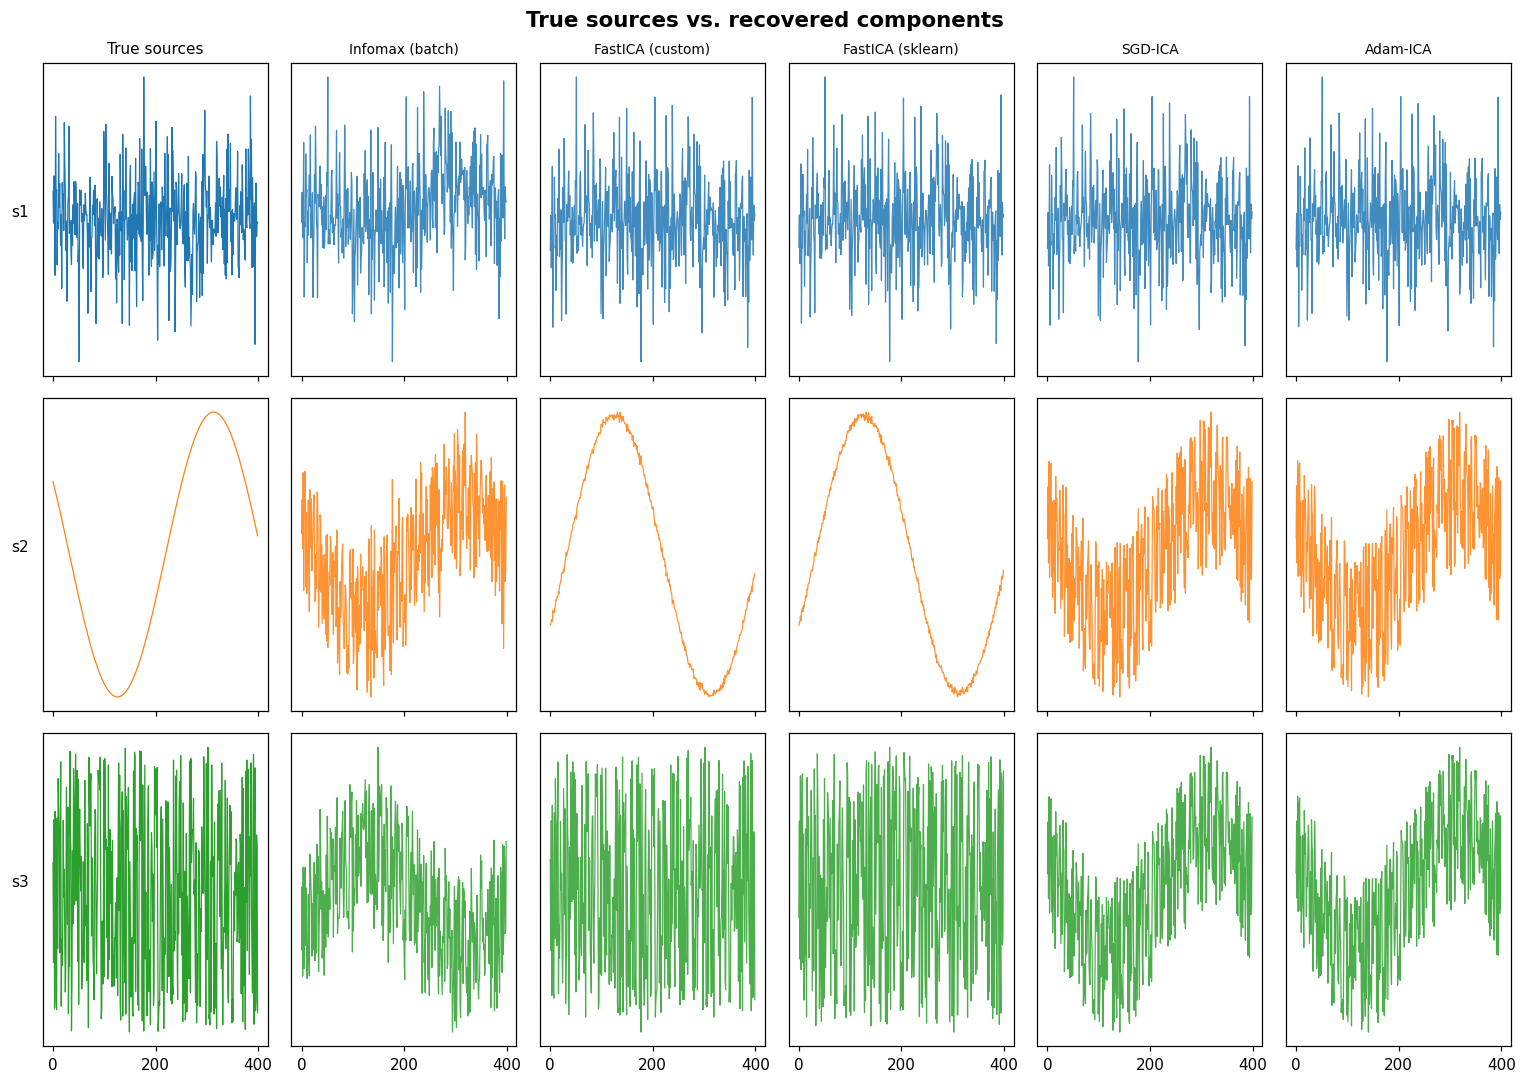

In [3]:
from experiments.visualization import plot_sources, plot_convergence, plot_amari_scores

S_true = results['_meta']['S']

fig = plot_sources(S_true, results, n_show=400)
plt.show()

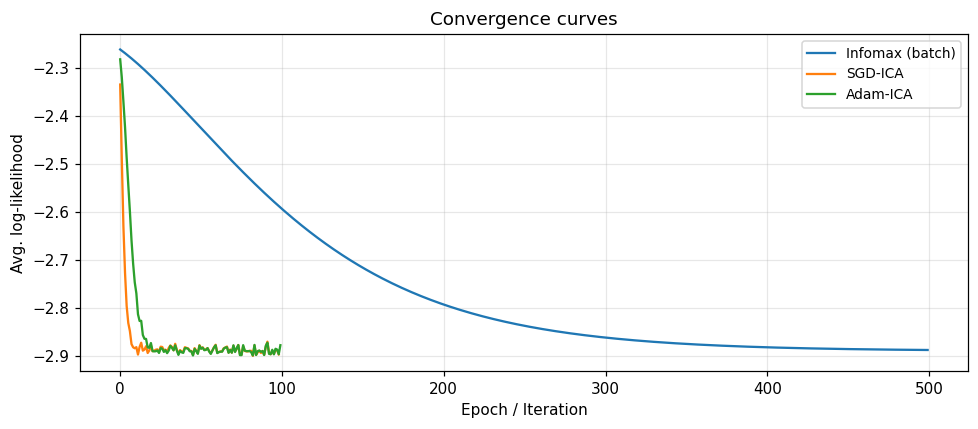

In [4]:
fig = plot_convergence(results)
plt.show()

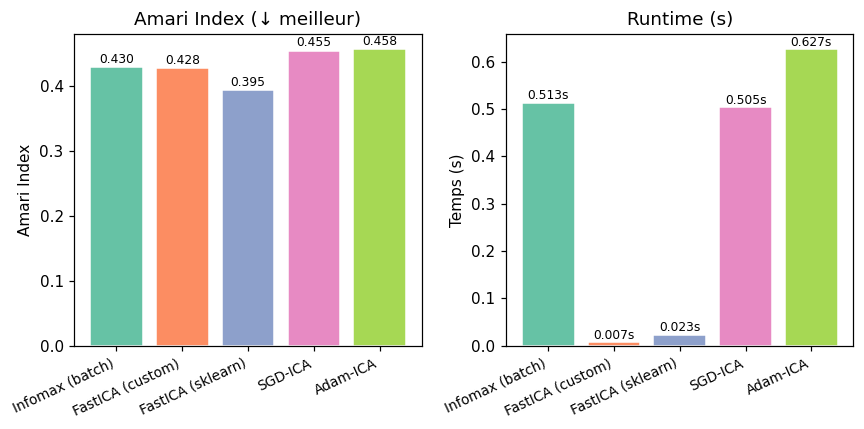

In [5]:
fig = plot_amari_scores(results)
plt.show()

## 7. Scalabilité : SGD-ICA et Adam-ICA sur grands datasets

L'avantage principal des méthodes stochastiques est leur capacité à traiter
de grandes quantités de données sans charger tout le dataset en mémoire.

In [ ]:
from ica import InfomaxICA, SGDICA, AdamICA
from experiments.benchmark import make_sources
import time

import time

sizes = [1_000, 5_000, 20_000, 50_000]
times_sgd, times_adam, times_infomax = [], [], []

for n in sizes:
    _, _, X_large = make_sources(n_samples=n, n_sources=3, random_state=0)

    t0 = time.perf_counter()
    SGDICA(n_components=3, n_epochs=30, batch_size=128, random_state=0).fit(X_large)
    times_sgd.append(time.perf_counter() - t0)

    t0 = time.perf_counter()
    AdamICA(n_components=3, n_epochs=30, batch_size=128, random_state=0).fit(X_large)
    times_adam.append(time.perf_counter() - t0)

    t0 = time.perf_counter()
    InfomaxICA(n_components=3, max_iter=200, random_state=0).fit(X_large)
    times_infomax.append(time.perf_counter() - t0)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sizes, times_infomax, 'o-', label='Infomax (batch)', color='#e74c3c')
ax.plot(sizes, times_sgd, 's-', label='SGD-ICA', color='#3498db')
ax.plot(sizes, times_adam, '^-', label='Adam-ICA', color='#2ecc71')
ax.set_xlabel('Nombre d\'échantillons')
ax.set_ylabel('Temps (s)')
ax.set_title('Scalabilité : temps d\'entraînement vs. taille du dataset')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. VAE-ICA — Séparation variationnelle non-linéaire

Le VAE-ICA étend l'ICA classique à des **mélanges non-linéaires** :
- L'**encodeur** MLP apprend \phi(z|x) = \mathcal{N}(\mu_\phi(x), \sigma^2_\phi(x))$
- Le **décodeur** MLP apprend \theta(x|z)$
- La **loss** combine reconstruction + KL + HSIC (indépendance)

\mathcal{L} = \underbrace{\|x - \hat{x}\|^2}_{\text{reconstruction}} + \beta \underbrace{\text{KL}(q_\phi \| \mathcal{N}(0,I))}_{\text{gaussien}} + \lambda \underbrace{\text{HSIC}(z_1, \ldots, z_k)}_{\text{indépendance}}

**Tension fondamentale** : le KL pousse $ vers une gaussienne, mais l'ICA requiert des sources **non-gaussiennes**. On contrôle cela via $\beta$ faible et $\lambda$ élevé.

In [4]:
from ica import VAEICA

vae_ica = VAEICA(
    n_components=3,
    hidden_dim=64,
    learning_rate=1e-3,
    beta=0.5,           # relâché pour permettre z non-gaussien
    lambda_hsic=10.0,   # fort pour forcer l'indépendance
    n_epochs=80,
    batch_size=64,
    sigma_hsic=1.0,
    random_state=42,
    verbose=True,
)
S_vae = vae_ica.fit_transform(X)
print(f'\nShape sources estimées : {S_vae.shape}')

[VAE-ICA] Epoch   0  loss=1.0624  rec=0.7348  kl=0.0711  hsic=0.0060
[VAE-ICA] Epoch   1  loss=0.7979  rec=0.4450  kl=0.3320  hsic=0.0063
[VAE-ICA] Epoch   2  loss=0.6810  rec=0.3792  kl=0.3854  hsic=0.0055
[VAE-ICA] Epoch   3  loss=0.6410  rec=0.3236  kl=0.5117  hsic=0.0128
[VAE-ICA] Epoch   4  loss=0.6093  rec=0.3018  kl=0.4661  hsic=0.0030
[VAE-ICA] Epoch   5  loss=0.6054  rec=0.2493  kl=0.4984  hsic=0.0045
[VAE-ICA] Epoch   6  loss=0.5945  rec=0.2144  kl=0.5274  hsic=0.0051
[VAE-ICA] Epoch   7  loss=0.5898  rec=0.2793  kl=0.6223  hsic=0.0096
[VAE-ICA] Epoch   8  loss=0.5901  rec=0.2222  kl=0.5593  hsic=0.0043
[VAE-ICA] Epoch   9  loss=0.5941  rec=0.2082  kl=0.6044  hsic=0.0078
[VAE-ICA] Epoch  10  loss=0.5886  rec=0.2673  kl=0.6274  hsic=0.0064
[VAE-ICA] Epoch  11  loss=0.5868  rec=0.2388  kl=0.5203  hsic=0.0056
[VAE-ICA] Epoch  12  loss=0.5860  rec=0.2741  kl=0.5296  hsic=0.0041
[VAE-ICA] Epoch  13  loss=0.5909  rec=0.2142  kl=0.5869  hsic=0.0084
[VAE-ICA] Epoch  14  loss=0.5934  

### 8a. Effet de β sur la distribution de z

Un β élevé force z vers N(0,I) → incompatible ICA.  
Un β faible laisse z libre → compatible avec des sources non-gaussiennes.

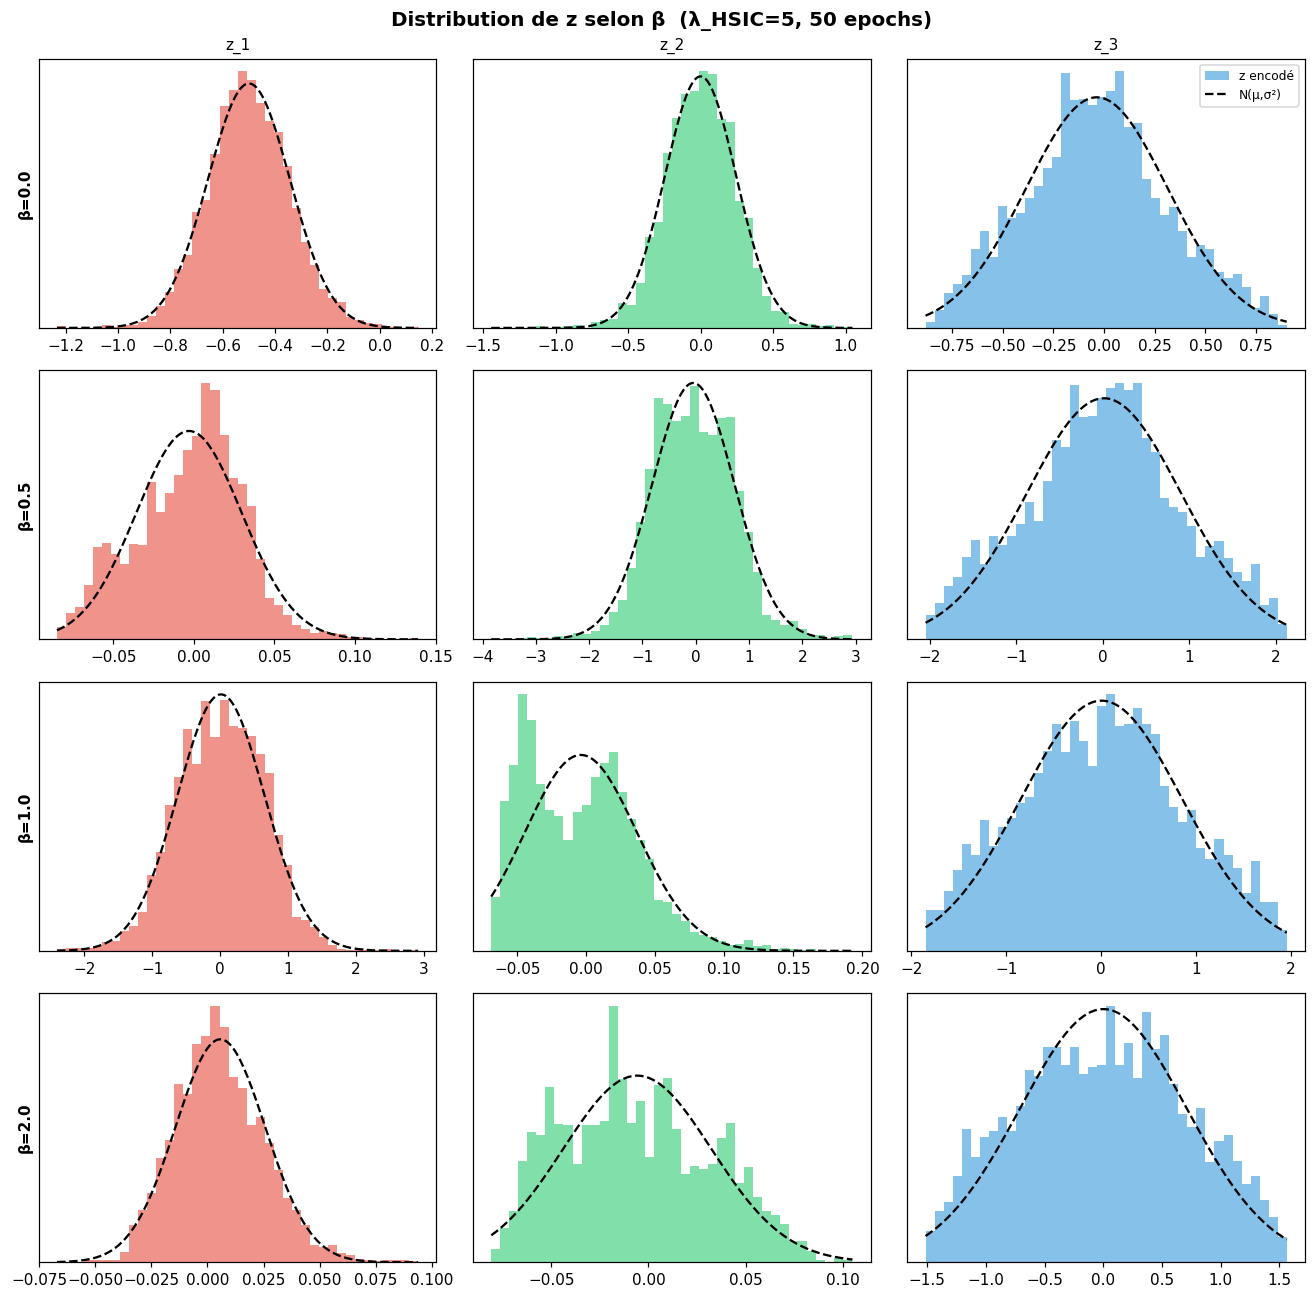

In [5]:
from scipy import stats

betas = [0.0, 0.5, 1.0, 2.0]
fig, axes = plt.subplots(len(betas), 3, figsize=(12, 3 * len(betas)), sharey=False)
fig.suptitle('Distribution de z selon β  (λ_HSIC=5, 50 epochs)', fontsize=13, fontweight='bold')

for row, beta in enumerate(betas):
    m = VAEICA(n_components=3, hidden_dim=64, learning_rate=1e-3,
               beta=beta, lambda_hsic=5.0, n_epochs=50, batch_size=64,
               random_state=42, verbose=False)
    Z = m.fit_transform(X)

    for col in range(3):
        ax = axes[row, col]
        z_j = Z[:, col]
        ax.hist(z_j, bins=40, density=True, alpha=0.6, color=colors[col], label='z encodé')
        # Gaussienne de référence
        xg = np.linspace(z_j.min(), z_j.max(), 200)
        ax.plot(xg, stats.norm.pdf(xg, z_j.mean(), z_j.std()), 'k--', lw=1.5, label='N(μ,σ²)')
        if col == 0:
            ax.set_ylabel(f'β={beta}', fontsize=10, fontweight='bold')
        if row == 0:
            ax.set_title(f'z_{col+1}', fontsize=10)
        ax.set_yticks([])

axes[0, 2].legend(fontsize=8)
plt.tight_layout()
plt.show()

### 8b. Effet de λ_HSIC sur l'indépendance des composantes

La matrice de corrélation de z doit tendre vers I (diagonale) quand λ augmente.

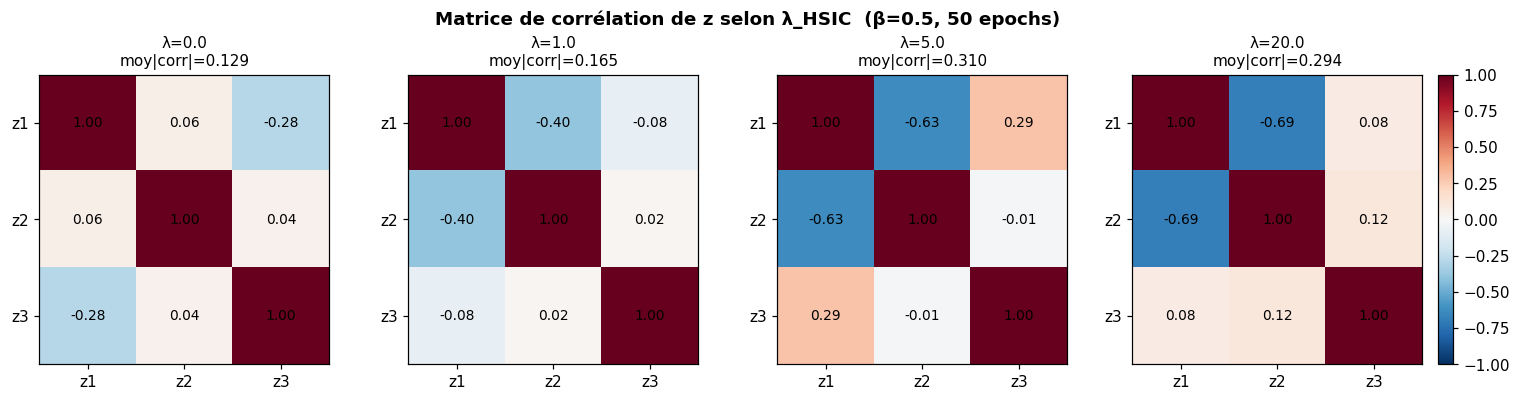

In [6]:
lambdas = [0.0, 1.0, 5.0, 20.0]
fig, axes = plt.subplots(1, len(lambdas), figsize=(14, 3.5))
fig.suptitle('Matrice de corrélation de z selon λ_HSIC  (β=0.5, 50 epochs)',
             fontsize=12, fontweight='bold')

for ax, lam in zip(axes, lambdas):
    m = VAEICA(n_components=3, hidden_dim=64, learning_rate=1e-3,
               beta=0.5, lambda_hsic=lam, n_epochs=50, batch_size=64,
               random_state=42, verbose=False)
    Z = m.fit_transform(X)
    corr = np.corrcoef(Z.T)
    off = corr[np.triu_indices(3, k=1)]

    im = ax.imshow(corr, vmin=-1, vmax=1, cmap='RdBu_r')
    ax.set_title(f'λ={lam}\nmoy|corr|={np.abs(off).mean():.3f}', fontsize=10)
    ax.set_xticks([0,1,2]); ax.set_xticklabels(['z1','z2','z3'])
    ax.set_yticks([0,1,2]); ax.set_yticklabels(['z1','z2','z3'])
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f'{corr[i,j]:.2f}', ha='center', va='center', fontsize=9)

plt.colorbar(im, ax=axes[-1], fraction=0.046)
plt.tight_layout()
plt.show()

### 8c. Courbe de convergence et composantes récupérées

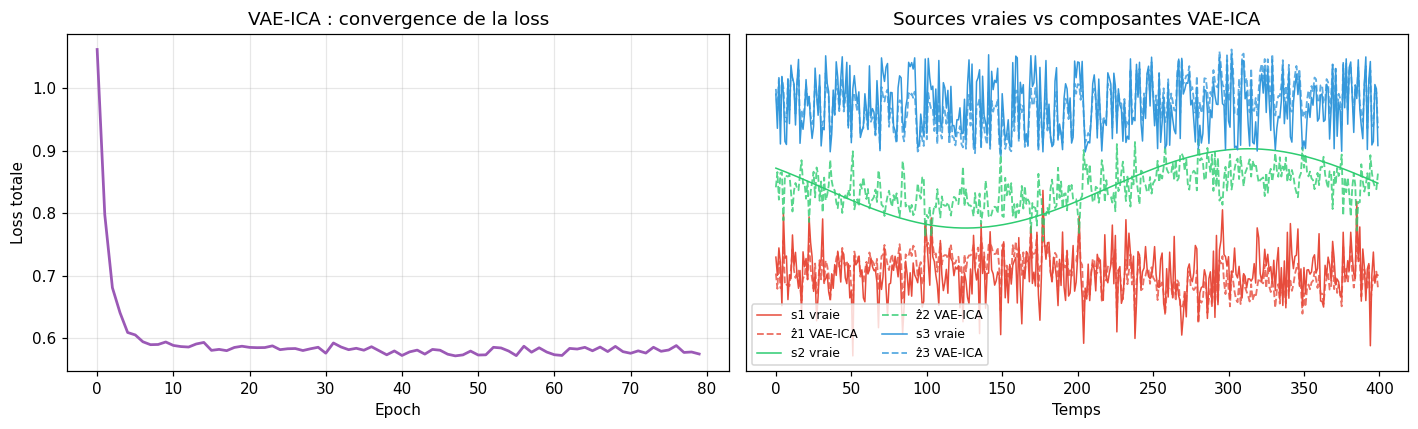

VAE-ICA  |  corr moy=0.2214  max=0.6022


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# ── Convergence ──
axes[0].plot(vae_ica.loss_curve_, color='#9b59b6', linewidth=1.8)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss totale')
axes[0].set_title('VAE-ICA : convergence de la loss')
axes[0].grid(True, alpha=0.3)

# ── Sources récupérées vs vraies ──
t = np.arange(400)
for j in range(3):
    # Aligne le signe par corrélation maximale
    corr_vals = [np.corrcoef(S[:400, j], S_vae[:400, c])[0,1] for c in range(3)]
    best = int(np.argmax(np.abs(corr_vals)))
    sign = np.sign(corr_vals[best])
    axes[1].plot(t, S[:400, j] + j*3, color=colors[j], lw=1.0, label=f's{j+1} vraie')
    axes[1].plot(t, sign * S_vae[:400, best] + j*3, color=colors[j],
                 lw=1.2, linestyle='--', alpha=0.8, label=f'ẑ{j+1} VAE-ICA')

axes[1].set_title('Sources vraies vs composantes VAE-ICA')
axes[1].set_xlabel('Temps')
axes[1].legend(fontsize=8, ncol=2)
axes[1].set_yticks([])
plt.tight_layout()
plt.show()

# Résumé
corr_vae = np.corrcoef(S_vae.T)
off_vae = corr_vae[np.triu_indices(3, k=1)]
print(f'VAE-ICA  |  corr moy={np.abs(off_vae).mean():.4f}  max={np.abs(off_vae).max():.4f}')

---

## 9. Application sur données EEG réelles (MNE-Python)

L'ICA est une technique standard en neurosciences pour **séparer les artefacts** des signaux cérébraux :

| Composante | Source |
|---|---|
| Signal cérébral | Oscillations neuronales (alpha, beta, theta...) |
| Artefact oculaire | Clignements, mouvements des yeux (EOG) |
| Artefact musculaire | Tension musculaire (EMG) |

On compare ici **FastICA (sklearn)** et **VAE-ICA** sur le dataset `sample` de MNE-Python (enregistrement MEG/EEG, sujet sain, stimuli auditifs/visuels).

Canaux EEG : 60
Durée      : 277.7 s
Fréq. éch. : 150 Hz


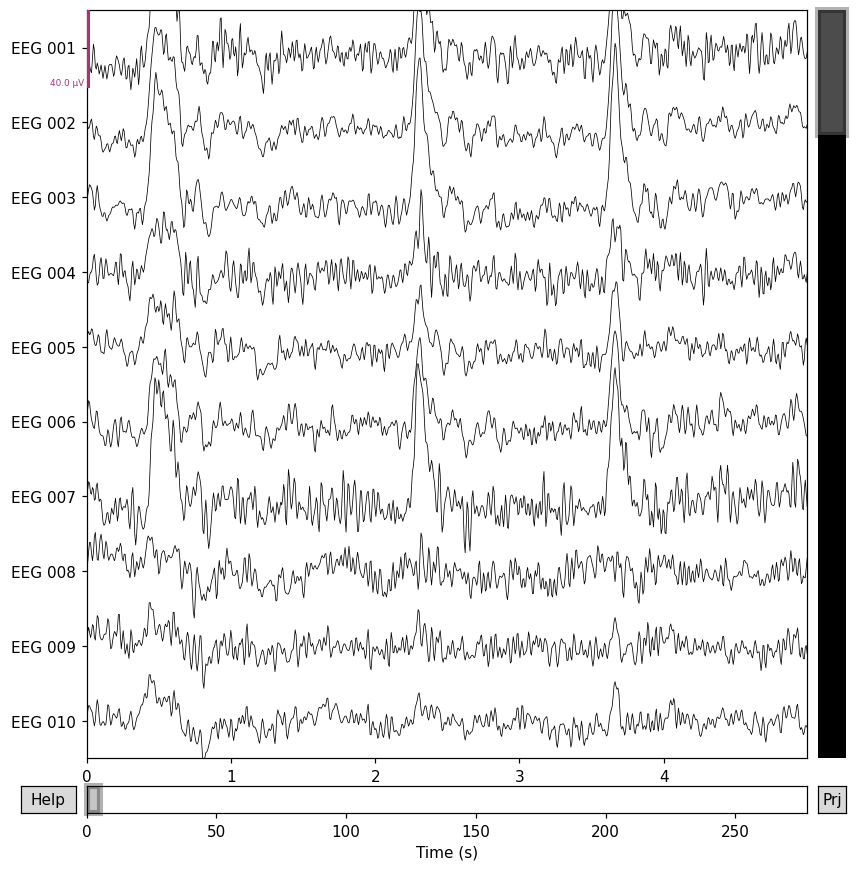

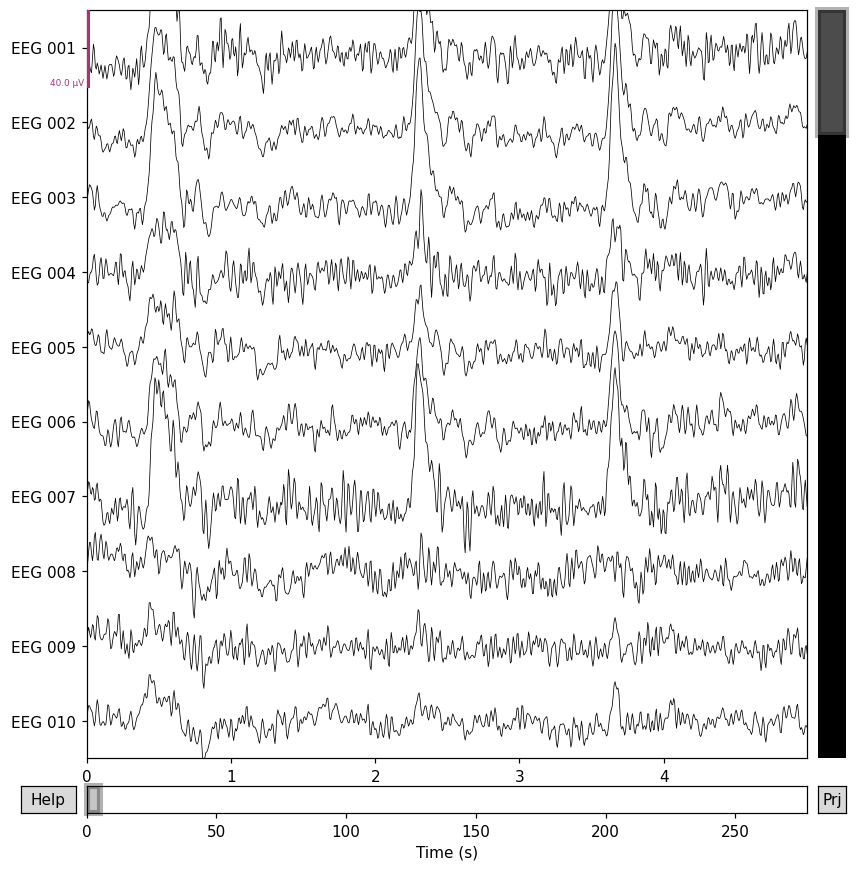

In [10]:
import mne
mne.set_log_level('WARNING')

# Chargement du dataset sample MNE (téléchargement automatique ~1.5GB si absent)
sample_data_folder = mne.datasets.sample.data_path()
sample_data_raw_file = sample_data_folder / 'MEG' / 'sample' / 'sample_audvis_filt-0-40_raw.fif'

raw = mne.io.read_raw_fif(sample_data_raw_file, preload=True, verbose=False)

# On garde uniquement les canaux EEG
raw.pick_types(meg=False, eeg=True, eog=True, exclude='bads')
raw.filter(1., 40., fir_design='firwin', verbose=False)

print(f'Canaux EEG : {len(raw.ch_names)}')
print(f'Durée      : {raw.times[-1]:.1f} s')
print(f'Fréq. éch. : {raw.info["sfreq"]:.0f} Hz')
raw.plot(n_channels=10, duration=5, title='Signal EEG brut (5 premières secondes)', block=False)

### 9a. Préparation des données EEG

On extrait la matrice X de dimension **(n_samples × n_channels)** à partir du signal brut.

X_eeg shape : (41700, 59)  (n_samples × n_channels)
Composantes ICA extraites : 20


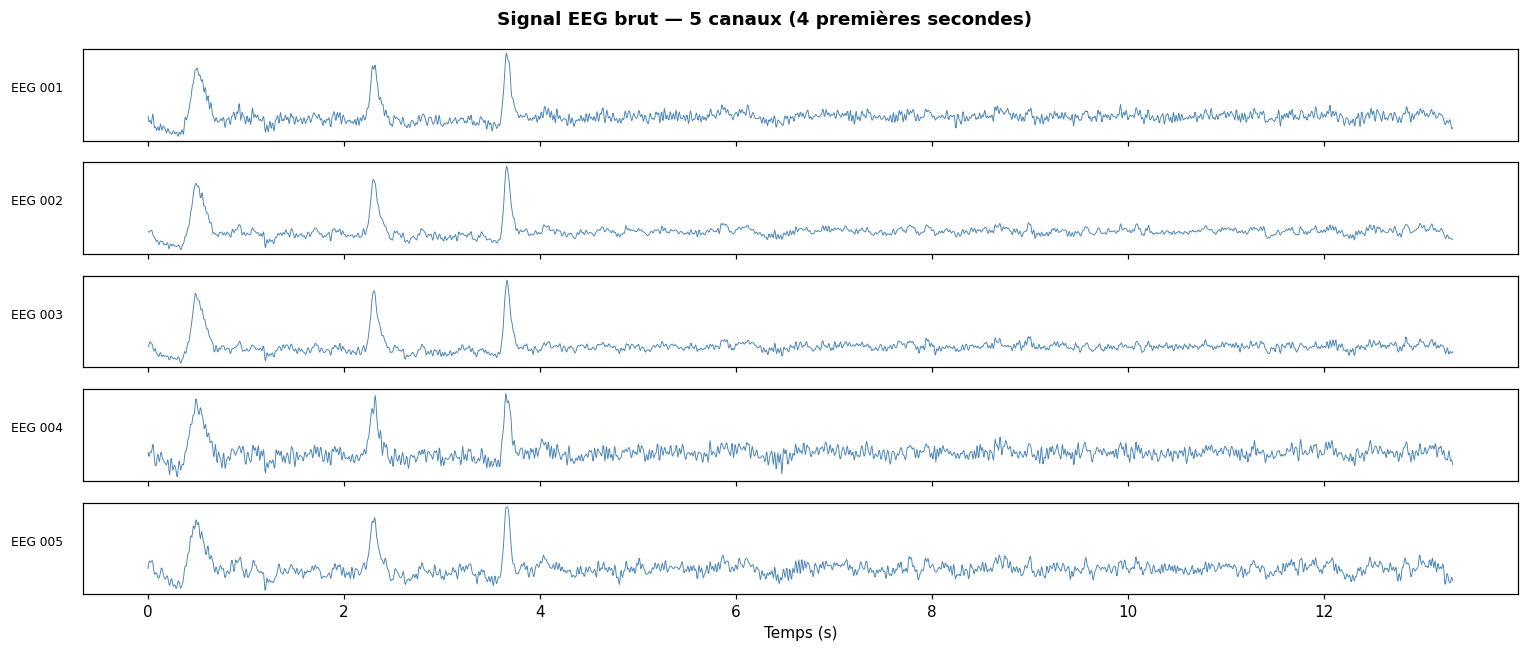

In [11]:
# Extraction de la matrice signal (canaux EEG uniquement, sans EOG)
eeg_picks = mne.pick_types(raw.info, meg=False, eeg=True, eog=False)
X_eeg = raw.get_data(picks=eeg_picks).T          # (n_samples, n_channels)
ch_names = [raw.ch_names[p] for p in eeg_picks]

# Normalisation
X_eeg = (X_eeg - X_eeg.mean(axis=0)) / X_eeg.std(axis=0)

n_components_eeg = 20    # nombre de composantes ICA
t_eeg = np.arange(X_eeg.shape[0]) / raw.info['sfreq']

print(f'X_eeg shape : {X_eeg.shape}  (n_samples × n_channels)')
print(f'Composantes ICA extraites : {n_components_eeg}')

# Visualisation de 5 canaux bruts
fig, axes = plt.subplots(5, 1, figsize=(14, 6), sharex=True)
for i, ax in enumerate(axes):
    ax.plot(t_eeg[:2000], X_eeg[:2000, i], lw=0.6, color='steelblue')
    ax.set_ylabel(ch_names[i], fontsize=8, rotation=0, labelpad=30)
    ax.set_yticks([])
axes[-1].set_xlabel('Temps (s)')
fig.suptitle('Signal EEG brut — 5 canaux (4 premières secondes)', fontweight='bold')
plt.tight_layout()
plt.show()

### 9b. FastICA sklearn sur EEG

FastICA est l'algorithme de référence en neurosciences (implémenté dans MNE nativement).

FastICA sklearn  —  1.73s  |  shape: (41700, 20)


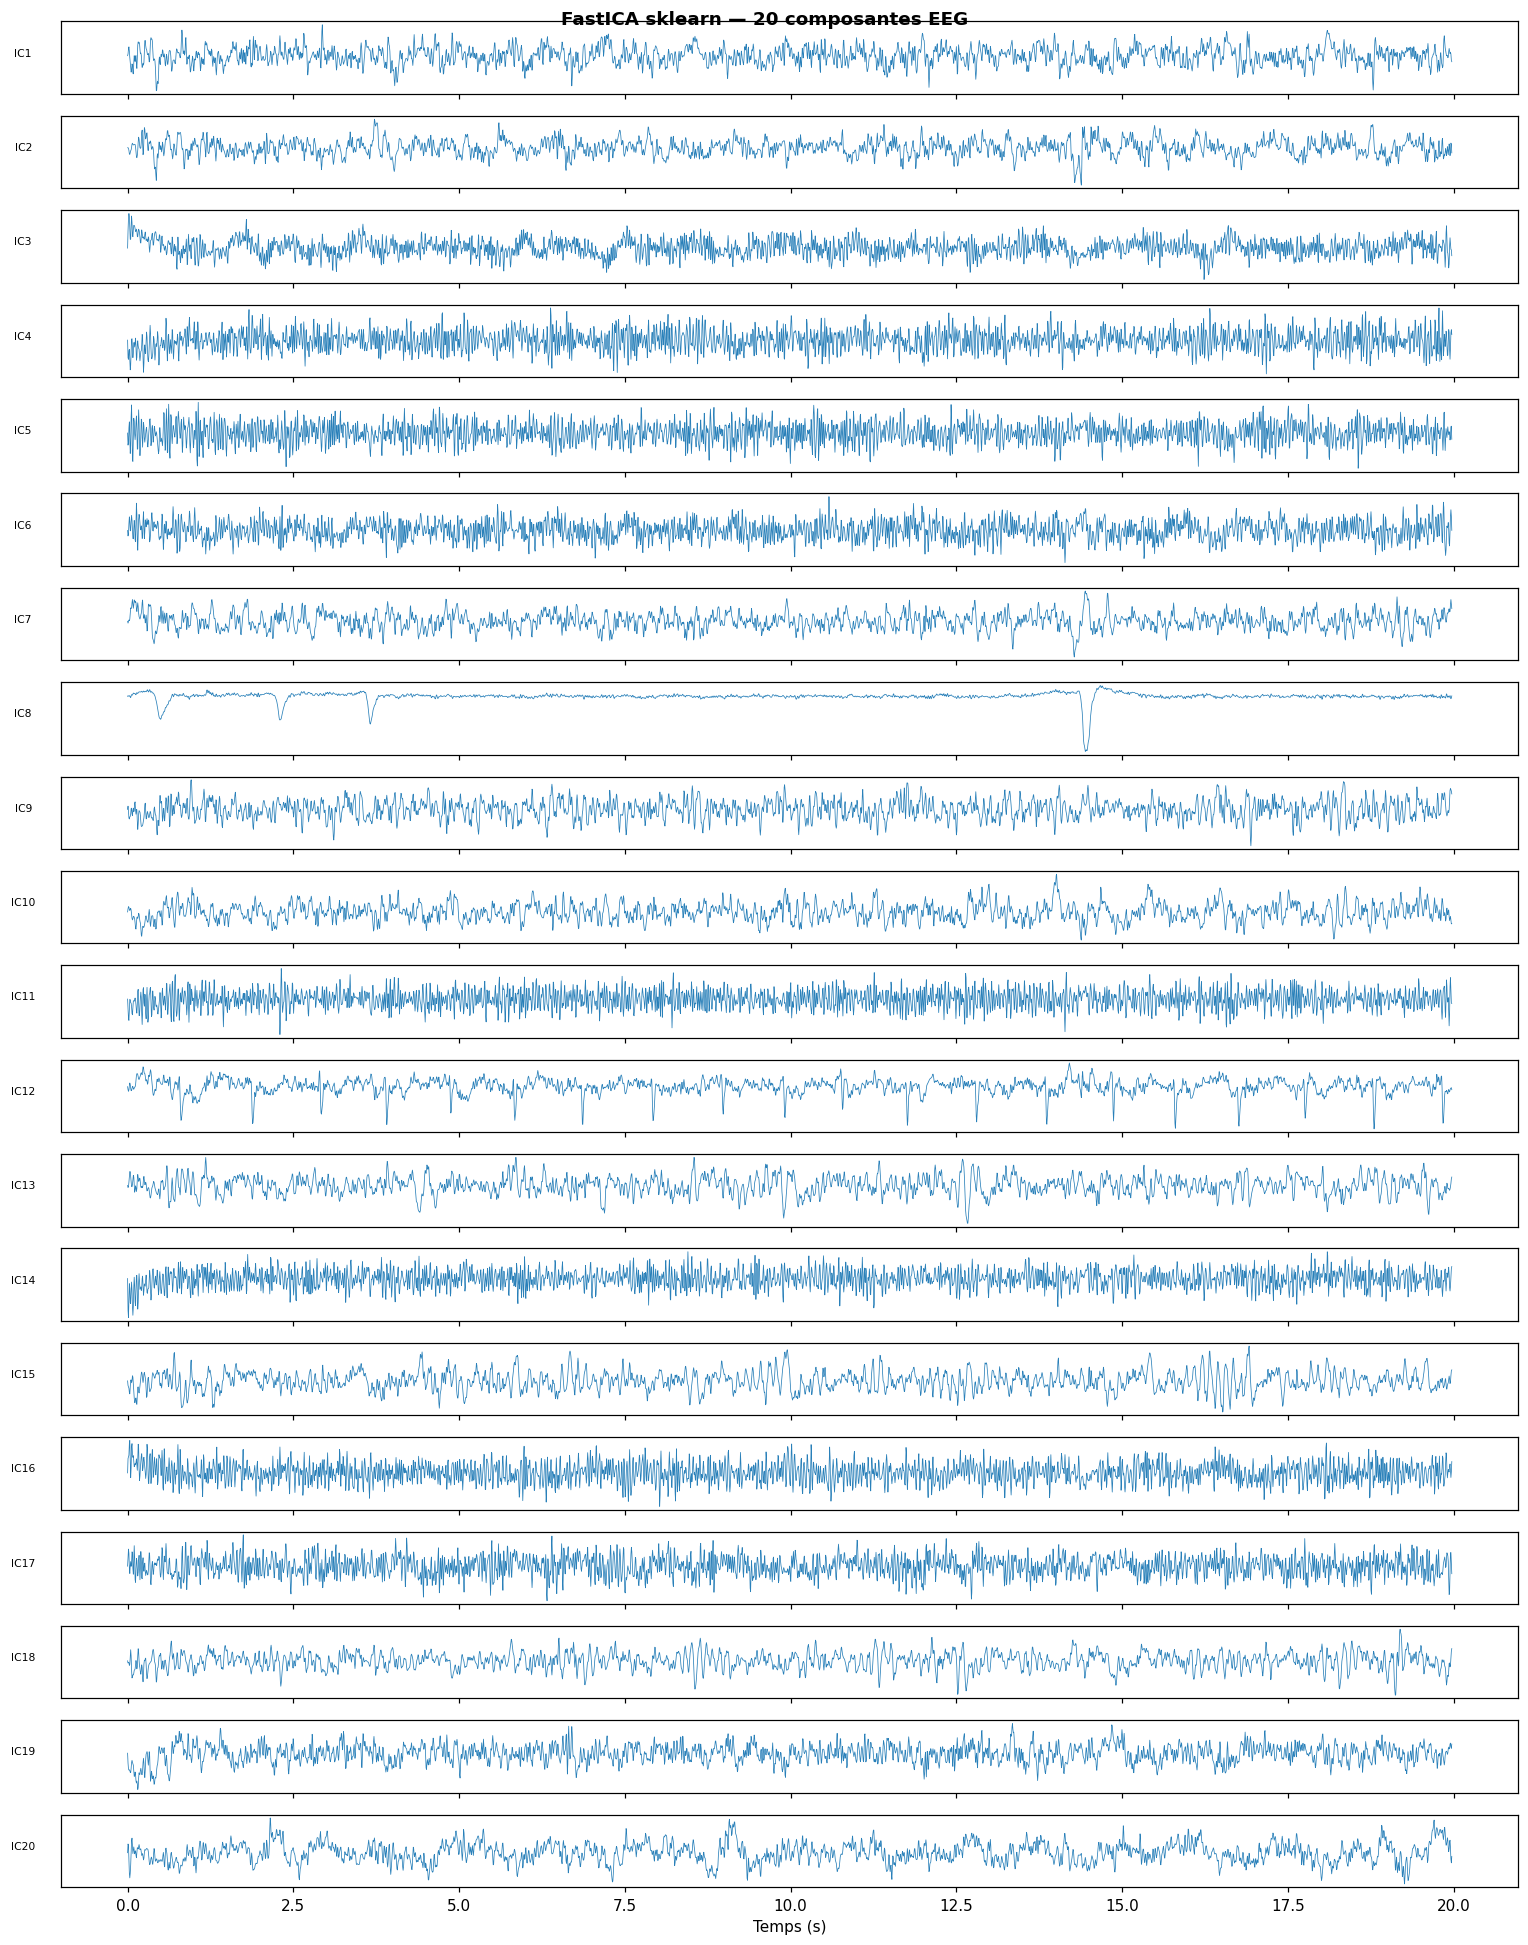

In [12]:
import time
from sklearn.decomposition import FastICA as SklearnFastICA

t0 = time.perf_counter()
fastica_eeg = SklearnFastICA(n_components=n_components_eeg, random_state=42, max_iter=500)
S_fastica_eeg = fastica_eeg.fit_transform(X_eeg)
t_fastica = time.perf_counter() - t0

print(f'FastICA sklearn  —  {t_fastica:.2f}s  |  shape: {S_fastica_eeg.shape}')

# Plot des 20 composantes ICA
fig, axes = plt.subplots(n_components_eeg, 1, figsize=(14, n_components_eeg * 0.9), sharex=True)
fig.suptitle(f'FastICA sklearn — {n_components_eeg} composantes EEG', fontweight='bold', fontsize=12)
for i, ax in enumerate(axes):
    ax.plot(t_eeg[:3000], S_fastica_eeg[:3000, i], lw=0.5, color='#2980b9')
    ax.set_ylabel(f'IC{i+1}', fontsize=7, rotation=0, labelpad=25)
    ax.set_yticks([])
axes[-1].set_xlabel('Temps (s)')
plt.tight_layout()
plt.show()

### 9c. VAE-ICA sur EEG

Le VAE-ICA apprend une séparation **non-linéaire** — potentiellement plus adaptée aux artefacts non-linéaires (clignements, mouvements).

In [14]:
# Sous-echantillonnage agressif : HSIC est O(batch^2 * k^2)
N_SUB = 2000     # echantillons d'entrainement
N_INFER = 10000  # echantillons pour l'inference / plots
idx = np.random.default_rng(42).choice(len(X_eeg), N_SUB, replace=False)
X_eeg_sub = X_eeg[idx]

t0 = time.perf_counter()
vae_eeg = VAEICA(
    n_components=n_components_eeg,
    hidden_dim=32,        # plus leger
    learning_rate=1e-3,
    beta=0.3,
    lambda_hsic=1.0,
    batch_size=64,        # batch plus petit = moins de calcul kernel
    n_epochs=10,
    sigma_hsic=2.0,
    random_state=42,
    verbose=True,
)
vae_eeg.fit(X_eeg_sub)
t_vae = time.perf_counter() - t0

# Inference sur un sous-ensemble pour la visu
S_vae_eeg = vae_eeg.transform(X_eeg[:N_INFER])
print(f"VAE-ICA : {t_vae:.2f}s  |  shape: {S_vae_eeg.shape}")

fig, axes = plt.subplots(n_components_eeg, 1, figsize=(14, 3 * n_components_eeg))
for i, ax in enumerate(axes):
    ax.plot(S_vae_eeg[:2000, i], lw=0.5)
    ax.set_title(f"VAE-ICA composante {i+1}")
    ax.set_xlabel("Echantillon")
plt.tight_layout()
plt.show()


KeyboardInterrupt: 

### 9d. Comparaison : indépendance des composantes

On mesure la corrélation croisée entre composantes — un bon ICA doit produire des composantes **décorrélées**.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Corrélation signal brut (référence)
corr_raw = np.corrcoef(X_eeg[:N_INFER, :n_components_eeg].T)
im0 = axes[0].imshow(np.abs(corr_raw), vmin=0, vmax=1, cmap='hot_r')
axes[0].set_title(f'EEG brut\n(moy|corr|={np.abs(corr_raw[np.triu_indices(n_components_eeg,k=1)]).mean():.3f})')
plt.colorbar(im0, ax=axes[0])

# FastICA
corr_fastica = np.corrcoef(S_fastica_eeg[:N_INFER].T)
off_f = np.abs(corr_fastica[np.triu_indices(n_components_eeg, k=1)]).mean()
im1 = axes[1].imshow(np.abs(corr_fastica), vmin=0, vmax=1, cmap='hot_r')
axes[1].set_title(f'FastICA sklearn\n(moy|corr|={off_f:.3f})  {t_fastica:.1f}s')
plt.colorbar(im1, ax=axes[1])

# VAE-ICA
corr_vae = np.corrcoef(S_vae_eeg.T)
off_v = np.abs(corr_vae[np.triu_indices(n_components_eeg, k=1)]).mean()
im2 = axes[2].imshow(np.abs(corr_vae), vmin=0, vmax=1, cmap='hot_r')
axes[2].set_title(f'VAE-ICA\n(moy|corr|={off_v:.3f})  {t_vae:.1f}s')
plt.colorbar(im2, ax=axes[2])

for ax in axes:
    ax.set_xlabel('Composante')
    ax.set_ylabel('Composante')

fig.suptitle('Matrice de corrélation absolue entre composantes ICA (EEG réel)\n↓ meilleur = plus proche de 0',
             fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()

print(f'\nRésumé :')
print(f'  EEG brut   corr moy = {np.abs(corr_raw[np.triu_indices(n_components_eeg,k=1)]).mean():.4f}')
print(f'  FastICA    corr moy = {off_f:.4f}   ({t_fastica:.2f}s)')
print(f'  VAE-ICA    corr moy = {off_v:.4f}   ({t_vae:.2f}s)')

### 9e. Reconstruction du signal après suppression d'artefacts

On identifie manuellement les composantes à rejeter (artefacts oculaires = grands pics basse fréquence), on les met à zéro et on reconstruit x̂ = V⁻¹ ẑ.

In [ ]:
# Identifier les composantes avec la plus grande variance basse fréquence
# (proxy simple pour les artefacts oculaires)
from scipy.signal import welch

def low_freq_power(signal, fs, f_max=4.0):
    """Puissance relative sous f_max Hz."""
    f, psd = welch(signal, fs=fs, nperseg=256)
    return psd[f < f_max].sum() / psd.sum()

fs = raw.info['sfreq']
artifacts_fastica = sorted(range(n_components_eeg),
                           key=lambda i: low_freq_power(S_fastica_eeg[:, i], fs),
                           reverse=True)[:3]  # 3 composantes les plus basse-fréq.

artifacts_vae = sorted(range(n_components_eeg),
                       key=lambda i: low_freq_power(S_vae_eeg[:, i], fs),
                       reverse=True)[:3]

print(f'Composantes artefacts identifiées :')
print(f'  FastICA : {[f"IC{i+1}" for i in artifacts_fastica]}')
print(f'  VAE-ICA : {[f"IC{i+1}" for i in artifacts_vae]}')

# Reconstruction après suppression
def reconstruct_clean(S, mixing, artifacts):
    S_clean = S.copy()
    S_clean[:, artifacts] = 0
    return S_clean @ mixing.T

mixing_fastica = fastica_eeg.mixing_
X_clean_fastica = reconstruct_clean(S_fastica_eeg, mixing_fastica, artifacts_fastica)

mixing_vae = vae_eeg.W_    # matrice de mélange estimée (linéaire approx.)
X_clean_vae = reconstruct_clean(S_vae_eeg, mixing_vae[:X_eeg.shape[1], :n_components_eeg], artifacts_vae)

# Visualisation : avant / après sur 1 canal
canal = 0
fig, axes = plt.subplots(3, 1, figsize=(14, 6), sharex=True)
t_show = t_eeg[:3000]

axes[0].plot(t_show, X_eeg[:3000, canal], color='gray', lw=0.7, label='EEG brut')
axes[0].set_title(f'Canal {ch_names[canal]} — EEG brut')
axes[0].set_yticks([])

axes[1].plot(t_show, X_clean_fastica[:3000, canal], color='#2980b9', lw=0.7, label='FastICA clean')
axes[1].set_title(f'Après suppression artefacts — FastICA sklearn')
axes[1].set_yticks([])

axes[2].plot(t_show, X_clean_vae[:3000, canal], color='#8e44ad', lw=0.7, label='VAE-ICA clean')
axes[2].set_title(f'Après suppression artefacts — VAE-ICA')
axes[2].set_yticks([])
axes[2].set_xlabel('Temps (s)')

plt.tight_layout()
plt.show()